# Task-1: Implementation of MCP Neurons.



For "AND" Operations.

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operation with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value.

    Returns:
    state_neuron (list): Output of neuron (1 or 0) for each pair of inputs.
    """
    assert len(X1) == len(X2)

    # Element-wise addition of inputs
    summed_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Store output states
    state_neuron = []

    # Apply threshold
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [2]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


For "OR" Operations.

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operation with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    T (int): Threshold value.

    Returns:
    state_neuron (list): Output of neuron (1 or 0) for each pair of inputs.
    """
    assert len(X1) == len(X2)

    # Element-wise addition of inputs
    summed_inputs = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Store output states
    state_neuron = []

    # Apply threshold
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question -1 : LIst out all the limiations of MCP - Neurons.

Answer:

MCP neurons can only solve linearly separable problems.

They cannot handle complex patterns like XOR.

They also use fixed weights and do not learn automatically.

Because of this, their real-world applications are limited.

Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.

Answer:

A single MCP neuron cannot solve the XOR function. This is because XOR is not linearly separable. To solve it, we need multiple neurons arranged in layers. This leads to the concept of neural networks.

# Task 2: Perceptron Algorithm for 0 vs 1 Classification.


Step 1: Load the Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AIandML/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question - 1: What does the shape of X represent?

Answer:
The shape of X = (12665, 784) indicates that the dataset contains 12,665 images. Each image is described using 784 features, representing the 28 × 28 pixel values. This means every row corresponds to a single image, while each column represents an individual pixel. Together, this forms the feature matrix used to train the model.

Question - 2: What does the shape of Y represent?

Answer:  

The shape of y = (12665, ) shows that there is a single label for each image in the dataset. Since there are 12,665 images, there are 12,665 corresponding labels. Each label represents the true class of its respective image. It is a one-dimensional array because each sample has only one output value.


Viewing the Dataset.

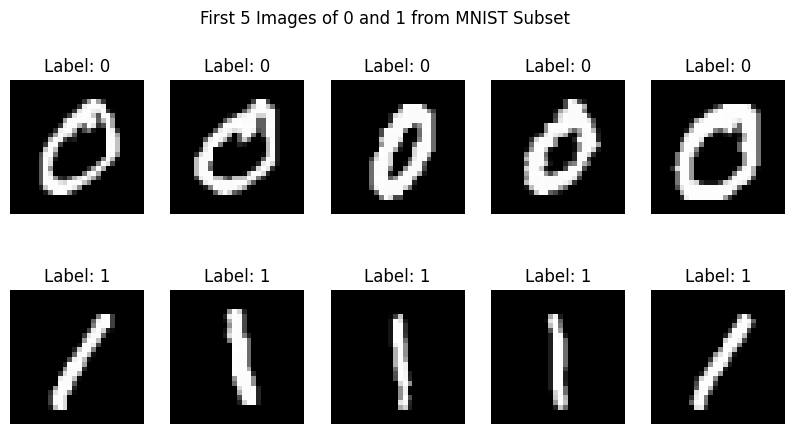

In [6]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

Step 2: Initializing the Weights

In [7]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question - 3: What does the weights array represent in this context?

Answer:

The weights array represents how important each input feature is, in this case each pixel. Since there are 784 pixels, there are 784 corresponding weights. During training, these weights are updated to help the model distinguish between the two classes more effectively. Higher weight values indicate that those pixels have a greater impact on the prediction.

Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Answer:

The weights are initialized to zero to start the training with no prior bias toward any feature. This means all pixels initially contribute equally to the prediction. During training, the weights are updated based on errors. Although simple, this initialization still allows the perceptron to learn effectively.

Step 3: Make a Decision function

In [8]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias

    y_pred_all = []
    for value in predictions:
        if value >= 0:
            y_pred_all.append(1)
        else:
            y_pred_all.append(0)

    return np.array(y_pred_all)

Step 4: Implement the Perceptron Learning Algorithm

In [9]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction
    """

    # Step 3: Perceptron Learning Algorithm
    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            # Compute linear output
            linear_output = np.dot(X[i], weights) + bias

            # Apply step activation function
            y_pred = 1 if linear_output >= 0 else 0

            # Compute error
            error = y[i] - y_pred

            # Update weights and bias if prediction is wrong
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

            # Count correct predictions
            if y_pred == y[i]:
                correct_predictions += 1

        accuracy = correct_predictions / len(X)

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Answer:

This line computes the linear output for a single image by multiplying its pixel values with the weights. The dot product combines all 784 features into one value. The bias is added to shift the decision boundary. This output is then used to decide whether the image is classified as 0 or 1.

Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?

Answer:

When the prediction is wrong, the error is calculated as the difference between actual and predicted values. The weights are updated using weights = weights + learning_rate × error × X[i]. The bias is also updated using bias = bias + learning_rate × error. This adjustment helps the model correct its mistakes in future predictions.

Question - 7: Why is the final accuracy important, and what do you expect it to be?

Answer:

Final accuracy shows how many images were correctly classified after training. It is calculated as the ratio of correct predictions to total samples. A high accuracy means the perceptron has learned the data well. Since digits 0 and 1 are simple, we expect the accuracy to be very high.

Training the Perceptron

In [10]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


Step 5: Visualize Misclassified Images


In [11]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question - 8:What does misclassified idx store, and how is it used in this code?

Answer:

misclassified_idx stores the indices of images where the predicted label does not match the actual label. It is computed using np.where(y_pred != y). These indices are then used to display wrongly classified images. This helps in analyzing where the model is making mistakes.

Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

Answer:

This means that the model predicted every image correctly with no errors. The misclassified_idx array is empty in this case. It indicates that the perceptron achieved 100% accuracy on the dataset. This usually happens when the data is clearly separable.

# Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AIandML/mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Unique labels:", np.unique(y))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Unique labels: [3 5]


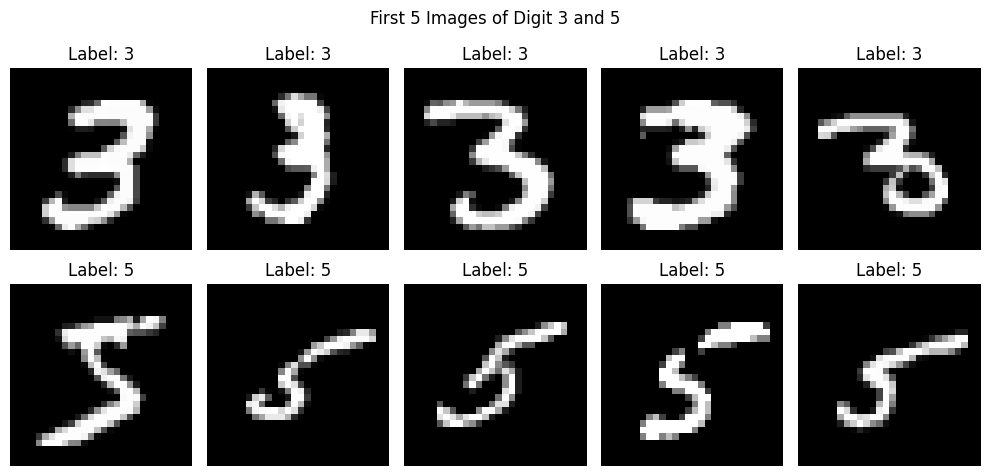

In [13]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of Digit 3 and 5")
    plt.tight_layout()
    plt.show()

In [14]:
y_binary = np.where(y == 3, 0, 1)

print("Converted labels:", np.unique(y_binary))

Converted labels: [0 1]


In [15]:
weights = np.zeros(X.shape[1])   # one weight for each feature
bias = 0
learning_rate = 0.1
epochs = 100

In [16]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using step activation function.
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

In [17]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train perceptron using the Perceptron Learning Algorithm.
    """
    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0

            error = y[i] - y_pred

            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

            if y_pred == y[i]:
                correct_predictions += 1

        accuracy = correct_predictions / len(X)
        print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.4f}")

    return weights, bias, accuracy

In [18]:
weights, bias, accuracy = train_perceptron(
    X, y_binary, weights, bias, learning_rate=0.1, epochs=100
)

print("Final Training Accuracy:", accuracy)

Epoch 1/100, Accuracy: 0.9157
Epoch 2/100, Accuracy: 0.9372
Epoch 3/100, Accuracy: 0.9416
Epoch 4/100, Accuracy: 0.9475
Epoch 5/100, Accuracy: 0.9489
Epoch 6/100, Accuracy: 0.9504
Epoch 7/100, Accuracy: 0.9599
Epoch 8/100, Accuracy: 0.9559
Epoch 9/100, Accuracy: 0.9540
Epoch 10/100, Accuracy: 0.9566
Epoch 11/100, Accuracy: 0.9599
Epoch 12/100, Accuracy: 0.9580
Epoch 13/100, Accuracy: 0.9657
Epoch 14/100, Accuracy: 0.9602
Epoch 15/100, Accuracy: 0.9635
Epoch 16/100, Accuracy: 0.9657
Epoch 17/100, Accuracy: 0.9606
Epoch 18/100, Accuracy: 0.9624
Epoch 19/100, Accuracy: 0.9610
Epoch 20/100, Accuracy: 0.9661
Epoch 21/100, Accuracy: 0.9701
Epoch 22/100, Accuracy: 0.9690
Epoch 23/100, Accuracy: 0.9730
Epoch 24/100, Accuracy: 0.9683
Epoch 25/100, Accuracy: 0.9650
Epoch 26/100, Accuracy: 0.9715
Epoch 27/100, Accuracy: 0.9734
Epoch 28/100, Accuracy: 0.9694
Epoch 29/100, Accuracy: 0.9715
Epoch 30/100, Accuracy: 0.9726
Epoch 31/100, Accuracy: 0.9668
Epoch 32/100, Accuracy: 0.9715
Epoch 33/100, Acc

In [19]:
y_pred_all = decision_function(X, weights, bias)

print("First 10 predictions:", y_pred_all[:10])

First 10 predictions: [1 0 0 1 0 0 0 1 0 1]


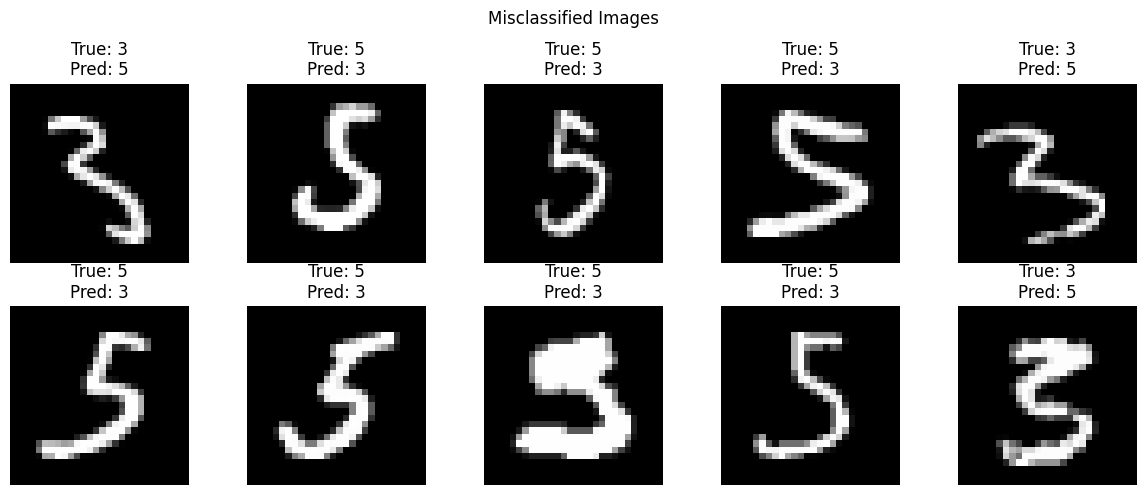

In [20]:
misclassified_indices = np.where(y_pred_all != y_binary)[0]
num_images = min(10, len(misclassified_indices))

plt.figure(figsize=(12, 5))

for i in range(num_images):
    idx = misclassified_indices[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    true_label = 3 if y_binary[idx] == 0 else 5
    predicted_label = 3 if y_pred_all[idx] == 0 else 5
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

In [21]:
final_accuracy = np.mean(y_pred_all == y_binary)
print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.986866107260124


Conclusion:

For the 3 vs 5 classification task, the perceptron reached a final accuracy of approximately 0.9869, or 98.69%. This indicates that the model effectively learned to distinguish between the two digits. A small number of images were still misclassified, likely because certain handwritten 3s and 5s resemble each other. Overall, the perceptron performed very strongly, though not as flawlessly as it did in the 0 vs 1 scenario.